# Code for cleanup and prep of updated weather and temp data

This notebook is for instructors to make it easier to update the data files to the most recent weather data

## To get the data 
- The data can be downloaded from this website: https://www.ncdc.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USW00014836/detail 
- It looks like you're requesting everything since 1948, but add the data to the cart, then in the checkout you can subset to be the dates you want. 
- When you checkout, they will email you a link to download the file. 
- Liz's code to clean up the data included in a separate jupyter notebook

In [42]:
# Imports 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import datetime
import matplotlib as mpl



# I keep getting a warning in plotting that it wants this, not clear why
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

### Previous data sets

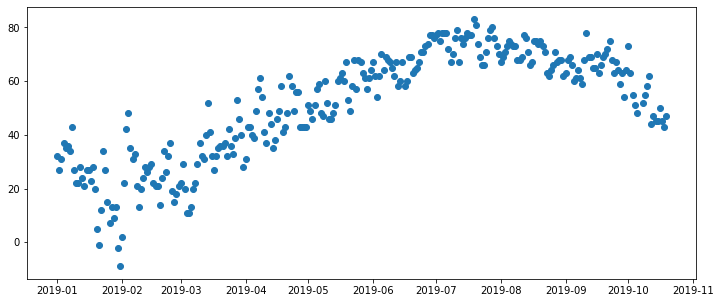

In [33]:
t2019_old = pd.read_csv("2019_temp_noaa.csv")

plt.figure(figsize = (12,5))

plt.plot_date(t2019_old['datenumber'],t2019_old['TAVG'])

In [34]:
w2019_old = pd.read_csv("2019_weather_noaa.csv")
w2019_old.head()

,STATION,NAME,DATE,AWND,PGTM,PRCP,SNOW,SNWD,TAVG,TMAX,...,WSF5,WT01,WT02,WT03,WT04,WT05,WT06,WT08,WT09,datenumber
0,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-01,8.05,NaN,0.02,0.0,0.0,32.0,34.0,...,19.9,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737060.0
1,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-02,8.28,NaN,0.05,NaN,0.0,27.0,33.0,...,25.9,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,737061.0
2,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-03,14.32,NaN,0.00,0.0,0.0,31.0,38.0,...,28.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737062.0
3,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-04,7.38,NaN,0.00,0.0,0.0,37.0,50.0,...,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737063.0
4,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-05,7.61,NaN,0.00,0.0,0.0,35.0,50.0,...,25.1,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,737064.0


In [35]:
w2019_old.columns

Index(['STATION', 'NAME', 'DATE', 'AWND', 'PGTM', 'PRCP', 'SNOW', 'SNWD',
       'TAVG', 'TMAX', 'TMIN', 'WDF2', 'WDF5', 'WSF2', 'WSF5', 'WT01', 'WT02',
       'WT03', 'WT04', 'WT05', 'WT06', 'WT08', 'WT09', 'datenumber'],
      dtype='object')

### New data set from NOAA


In [63]:
weather_all = pd.read_csv("RawFile2019-2020_DO-NOT-UPLOAD.csv")
weather_all = weather_all.drop(columns = ['LATITUDE','LONGITUDE','ELEVATION'])
weather_all.head()

,STATION,NAME,DATE,AWND,PGTM,PRCP,SNOW,SNWD,TAVG,TMAX,...,WSF2,WSF5,WT01,WT02,WT03,WT04,WT05,WT06,WT08,WT09
0,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-01,8.05,NaN,0.02,0.0,0.0,32.0,34.0,...,16.1,19.9,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-02,8.28,NaN,0.05,NaN,0.0,27.0,33.0,...,21.0,25.9,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN
2,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-03,14.32,NaN,0.00,0.0,0.0,31.0,38.0,...,21.0,28.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-04,7.38,NaN,0.00,0.0,0.0,37.0,50.0,...,18.1,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-05,7.61,NaN,0.00,0.0,0.0,35.0,50.0,...,19.9,25.1,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN


In [64]:
# Note we still need to put the datenumber back in here 
weather_all.columns

Index(['STATION', 'NAME', 'DATE', 'AWND', 'PGTM', 'PRCP', 'SNOW', 'SNWD',
       'TAVG', 'TMAX', 'TMIN', 'WDF2', 'WDF5', 'WSF2', 'WSF5', 'WT01', 'WT02',
       'WT03', 'WT04', 'WT05', 'WT06', 'WT08', 'WT09'],
      dtype='object')

In [65]:
    
weather_all["datenumber"] = 0.0
for i,d in enumerate(weather_all['DATE']):
    weather_all['datenumber'][i] = mpl.dates.date2num(datetime.datetime.strptime(d, "%Y-%m-%d"))

/home/liz/Programs/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [66]:
weather_all.head()

,STATION,NAME,DATE,AWND,PGTM,PRCP,SNOW,SNWD,TAVG,TMAX,...,WSF5,WT01,WT02,WT03,WT04,WT05,WT06,WT08,WT09,datenumber
0,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-01,8.05,NaN,0.02,0.0,0.0,32.0,34.0,...,19.9,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737060.0
1,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-02,8.28,NaN,0.05,NaN,0.0,27.0,33.0,...,25.9,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,737061.0
2,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-03,14.32,NaN,0.00,0.0,0.0,31.0,38.0,...,28.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737062.0
3,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-04,7.38,NaN,0.00,0.0,0.0,37.0,50.0,...,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737063.0
4,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-01-05,7.61,NaN,0.00,0.0,0.0,35.0,50.0,...,25.1,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,737064.0


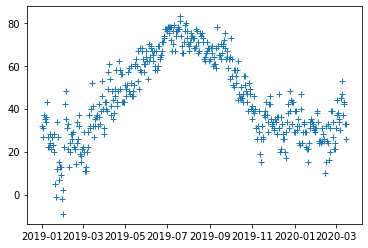

In [67]:
plt.plot_date(weather_all['datenumber'], weather_all['TAVG'], marker = '+')

### Extract 2019 data 

In [68]:
w2019 = weather_all[weather_all['DATE'] <= '2019-12-31']
w2019.tail()

,STATION,NAME,DATE,AWND,PGTM,PRCP,SNOW,SNWD,TAVG,TMAX,...,WSF5,WT01,WT02,WT03,WT04,WT05,WT06,WT08,WT09,datenumber
360,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-12-27,11.63,NaN,0.00,0.0,0.0,44.0,55.0,...,27.1,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,737420.0
361,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-12-28,6.93,NaN,0.00,0.0,0.0,33.0,39.0,...,21.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,737421.0
362,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-12-29,10.51,NaN,0.89,0.0,0.0,43.0,52.0,...,36.9,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,737422.0
363,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-12-30,18.12,NaN,1.41,0.0,0.0,43.0,51.0,...,47.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737423.0
364,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2019-12-31,16.11,NaN,0.18,2.5,2.0,29.0,31.0,...,35.1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737424.0


In [69]:
#Extract just the columns we want 
print(t2019_old.columns)

t2019 = w2019[t2019_old.columns]
t2019.head()

Index(['STATION', 'DATE', 'TAVG', 'TMAX', 'TMIN', 'datenumber'], dtype='object')


,STATION,DATE,TAVG,TMAX,TMIN,datenumber
0,USW00014836,2019-01-01,32.0,34.0,24.0,737060.0
1,USW00014836,2019-01-02,27.0,33.0,24.0,737061.0
2,USW00014836,2019-01-03,31.0,38.0,29.0,737062.0
3,USW00014836,2019-01-04,37.0,50.0,27.0,737063.0
4,USW00014836,2019-01-05,35.0,50.0,24.0,737064.0


In [70]:
# Overwrites old files 
w2019.to_csv("2019_weather_noaa.csv",index=False)
t2019.to_csv("2019_temp_noaa.csv",index=False)

### Extract 2020 data 

In [71]:
w2020 = weather_all[weather_all['DATE'] > '2019-12-31']
w2020.head()

,STATION,NAME,DATE,AWND,PGTM,PRCP,SNOW,SNWD,TAVG,TMAX,...,WSF5,WT01,WT02,WT03,WT04,WT05,WT06,WT08,WT09,datenumber
365,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2020-01-01,13.20,NaN,0.00,0.0,2.0,29.0,39.0,...,33.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737425.0
366,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2020-01-02,14.09,NaN,0.00,0.0,1.2,39.0,45.0,...,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737426.0
367,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2020-01-03,5.59,NaN,0.00,0.0,0.0,39.0,41.0,...,17.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737427.0
368,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2020-01-04,9.40,NaN,0.00,0.0,0.0,32.0,33.0,...,27.1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,737428.0
369,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",2020-01-05,12.97,NaN,0.02,0.0,0.0,30.0,36.0,...,35.1,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,737429.0


In [72]:
#Extract just the columns we want 
print(t2019_old.columns)

t2020 = w2020[t2019_old.columns]
t2020.head()

Index(['STATION', 'DATE', 'TAVG', 'TMAX', 'TMIN', 'datenumber'], dtype='object')


,STATION,DATE,TAVG,TMAX,TMIN,datenumber
365,USW00014836,2020-01-01,29.0,39.0,24.0,737425.0
366,USW00014836,2020-01-02,39.0,45.0,36.0,737426.0
367,USW00014836,2020-01-03,39.0,41.0,33.0,737427.0
368,USW00014836,2020-01-04,32.0,33.0,29.0,737428.0
369,USW00014836,2020-01-05,30.0,36.0,28.0,737429.0


In [73]:
# Overwrites old files 
w2020.to_csv("2020_weather_noaa.csv",index=False)
t2020.to_csv("2020_temp_noaa.csv",index=False)